# Sensitivity Study: Formulation of the source depletion term

This notebook gives insight to the different handling of the source depletion in the model classes implemented in *mibitrans*. It further showcases how a model class can be adapted to modify behaviour.

**Authors:** Jorrit Bakker, Alraune Zech

## Background

The equation solved by *BIOSCREEN*$^{1,2}$ uses the approximate (analytical) solution of Domenico (1987)$^3$ for multidimensional transport of a contaminant species, but with the addition of source depletion and source superposition. The same equation is implemented in the *mibitrans* packages as the `Bioscreen` model class. 

The source depletion term is expressed as:
$$C_0 \exp\left(-\gamma_s\left(t - \frac{x}{v}\right)\right)$$
This term is constructed from the fact that the concentrations at the advective front ($t = x/v$) originate from the source at an earlier time ($t - x/v$), where the source concentration has depleted less. So the term combines the decline in source concentration over time and the advective transport. However, the expression is not the result of exact mathematical derivation, but is instead superimposed onto the equation without source decay to get the equation for the `Bioscreen` model class. 

Karanovic et al (2007)$^4$ provided the mathematically sound exact solution where source depletion is integrated into the longitudinal advection and dispersion term. This equation is implemented in the `Mibitrans` model class.

## Anatrans model

The equation implemented in the `Anatrans` model class reads:
\begin{align}
    C(x,y,t) & = \sum_{i=1}^{n}\left\{ \frac{C^*_{0,i}}{8} \exp \left(-\gamma_s t\right)\cdot  \right. \\ 
    &\quad \left[\exp \left( \frac{x\left(1-\tilde P\right)}{2\alpha_x}\right) \right. \cdot \operatorname{erfc} \left( \frac{x - v_Rt\tilde P}{2\sqrt{\alpha_x v_Rt }} \right) \nonumber\\
    &\quad \ \, +  \left.\exp \left( \frac{x\left(1+\tilde P\right)}{2\alpha_x}\right) \cdot \operatorname{erfc} \left( \frac{x + v_Rt\tilde P}{2\sqrt{\alpha_x v_Rt }} \right) \right]\cdot \nonumber\\
    &\quad \left[ \operatorname{erf} \left( \frac{y + Y_i}{2\sqrt{\alpha_y x}} \right) - \operatorname{erf} \left( \frac{y - Y_i}{2\sqrt{\alpha_y x)}} \right) \right]\cdot \nonumber\\
    &\quad  \left. \left[ \operatorname{erf} \left( \frac{Z}{2\sqrt{\alpha_z x)}} \right) - \operatorname{erf} \left( \frac{-Z}{2\sqrt{\alpha_z x}} \right) \right] \right\} \nonumber
\end{align}

with $\tilde P = \sqrt{1+4 (\mu-\gamma_s) \alpha_x/v_R}$ that accounts for the advective components of the source depletion. 
Note that the handling of source depletion is convoluted in the term of $\tilde P$

## Alternative model

An intermediate model between Anatrans and Bioscreen is the following:
\begin{align}
C(x,y,t) &= \sum_{i=1}^{n}\left\{ \frac{C^*_{0,i}}{8} \exp \left(-\gamma_s \left(t-\frac{x}{v_R} \right)\right)\cdot  \right. \\ 
   &\quad \left[\exp \left( \frac{x\left(1-P\right)}{2\alpha_x}\right) \right. \cdot \operatorname{erfc} \left( \frac{x - v_RtP}{2\sqrt{\alpha_x v_Rt }} \right) \nonumber\\
   &\quad \ \, +  \left.\exp \left( \frac{x\left(1+P\right)}{2\alpha_x}\right) \cdot \operatorname{erfc} \left( \frac{x + v_RtP}{2\sqrt{\alpha_x v_Rt }} \right) \right]\cdot \nonumber\\
   &\quad \left[ \operatorname{erf} \left( \frac{y + Y_i}{2\sqrt{\alpha_y x}} \right) - \operatorname{erf} \left( \frac{y - Y_i}{2\sqrt{\alpha_y x)}} \right) \right]\cdot \nonumber\\
   &\quad  \left. \left[ \operatorname{erf} \left( \frac{Z}{2\sqrt{\alpha_z x)}} \right) - \operatorname{erf} \left( \frac{-Z}{2\sqrt{\alpha_z x}} \right) \right] \right\} \nonumber
\end{align}
with $P = \sqrt{1+4 \mu \alpha_x/v_R}$.

Here, the transport terms in horizontal direction are not truncated (as in `Bioscreen`), but source depletion is handled as in `Bioscreen`.

## Model setup

Model paramters are moslty those of the standard example in *mibitrans* (`getting_started.ipynb`). 

We chose a finite source mass which will automatically initialize source depletion at a rate $\gamma_s$:
$$    \gamma_s = \frac{Q \cdot \bar{C_{0}}}{m_\mathrm{s,0}} $$
where $\bar{C_{0}} = \frac{1}{Y}\sum_i Y_i\cdot C_{0,i}$ is the (weighted) average source concentration, $m_\mathrm{s,0}$ is the initial source mass, $Q = v \cdot \theta_e \cdot (2Y) \cdot (2Z)$ is the volumetric flow rate with $v$ being velocity, $\theta_e$ being porosity and $2Y$ and $2Z$ being source width and depth.

## References

$^1$ Newell, C. J., R. K. McLeod, and J. R. Gonzales (1996), BIOSCREEN Natural Attenuation Decision Support System User’s Manual Version 1.3, Tech. Rep. EPA/600/R-96/087, US EPA

$^2$ Newell, C. J., McLeod, R. K., & Gonzales, J. R. (1997), BIOSCREEN natural attenuation decision support system version 1.4 revisions, Tech. rep., U.S. EPA.

$^3$ [Domenico, P. A., 1987, An analytical model for multidimensional transport of a decaying contaminant
species, Journal of Hydrology, 91 (1), 49–58.](https://doi.org/10.1016/0022-1694(87)90127-2)

$^4$[Karanovic, M., C. J. Neville, and C. B. Andrews,(2007), BIOSCREEN-AT: BIOSCREEN with an exact analytical solution, Groundwater, 45 (2), 242–245.](https://doi.org/doi:10.1111/j.1745-6584.2006.00296.x)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mibitrans as mbt

## Costumize Model

Before setting up the model and running it, we actually want to create a "new" model class that has the same setting as the `Anatrans` model class, but uses the (simplified) version of source depletion as used in the `Bioscreen` model class. This will allow us to visualize the effect of the *BIOSCREEN* - source depletion with the mathematically exact formulation (while keeping all other implementation aspects identical).

We start with defining a custom class (named `AnatransAlternativeSource`) and initialize it with the same arguments as the `Anatrans` model class. It inherrits all the functionalities of `Anatrans` by assigning it as the parent class by putting it between parentheses behind the class name. 

In a second step, we adapt those parts that we want to be different from the of `Anatrans` model class. We do so by redefining the handling of the source depletion function `_equation_term_source_depletion()` and `_equation_decay_sqrt()`. 

In [2]:
# Give the custom class a new name and make it inherit from Anatrans as a child class.
class AnatransAlternativeSource(mbt.Anatrans):
    """Mibitrans model class with alternative source depletion."""
    # Unless otherwise specified, all functionalities are now the same as Anatrans
    # Change the equation terms to fit the alternative source depletion formulation.
    def _equation_term_source_depletion(self, xxx, ttt):
        term = np.exp(-self.k_source * (ttt - xxx / self.rv))
        # Term can be max 1; can not have 'generation' of solute ahead of advection.
        return np.where(term > 1, 1, term)

    def _equation_decay_sqrt(self):
        return np.sqrt(1 + 4 * self._decay_rate * self._hyd_pars.alpha_x / self.rv)

## Setup Data Input

In [3]:
hydro = mbt.HydrologicalParameters(velocity = 0.1, 
                                   porosity = 0.3,
                                   alpha_x = 3, 
                                   alpha_y = 0.02,
                                   alpha_z = 0.005)
att = mbt.AttenuationParameters(retardation = 1.0, 
                                half_life = 0)
source = mbt.SourceParameters(source_zone_boundary = [15], 
                              source_zone_concentration = [10],
                              depth = 2,
                              total_mass=25000 # [g]
                            )

model = mbt.ModelParameters(model_length = 500,
                            model_width = 60,
                            model_time = 10 * 365)

## Model run

In [4]:
### Initialize and run the mibitrans-standard model classes
bio_object = mbt.Bioscreen(hydro, att, source, model)
bio_results = bio_object.run()

ana_object = mbt.Anatrans(hydro, att, source, model)
ana_results = ana_object.run()

mbt_object = mbt.Mibitrans(hydro, att, source, model)
mbt_results = mbt_object.run()

In [5]:
### Initialize and run the alternative model class
alt_object = AnatransAlternativeSource(hydro, att, source, model)
alt_results = alt_object.run()

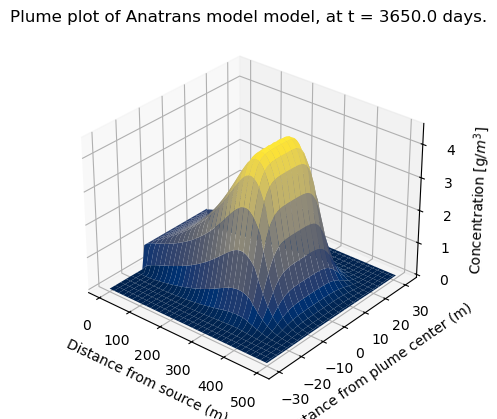

In [6]:
ax = alt_results.plume_3d(cmap="cividis")

## Visualize Results

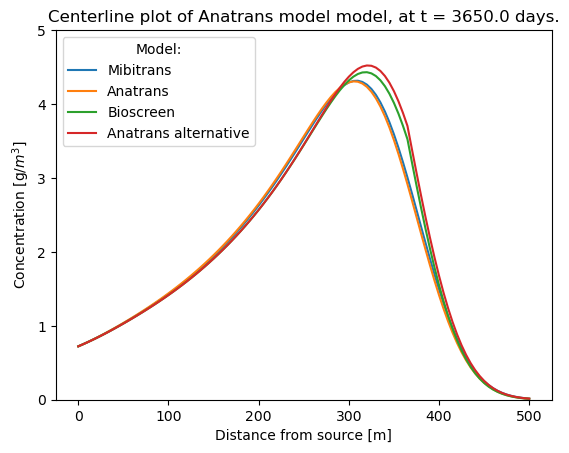

In [7]:
time = 365 * 10
mbt_results.centerline(time = time, color="C0", label="Mibitrans")
ana_results.centerline(time = time, color="C1", label="Anatrans")
bio_results.centerline(time = time, color="C2", label="Bioscreen")
alt_results.centerline(time = time, color="C3", label="Anatrans alternative")
plt.legend(title="Model:")
plt.ylim([0,5])
plt.show()

In [8]:
cmap = plt.get_cmap('tab20b')
colors_1 = cmap.colors   # list of RGB tuples

cmap = plt.get_cmap('Set1')
colors_2 = cmap.colors   # list of RGB tuples

ls_order = ['-','--',':','-.']
textsize = 8
lw = 2


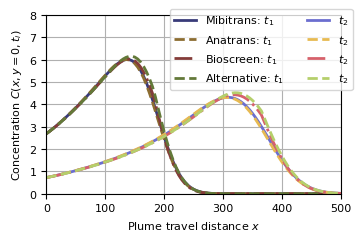

In [9]:
t1 = 5*365 #1y
#t2 = 3*365 #3y
t3 = 10*365 # 9y

plt.figure(figsize = [3.75,2.5])
mbt_results.centerline(time = t1, color=colors_1[0],ls = '-',lw=lw, label="Mibitrans: $t_1$")
ana_results.centerline(time = t1, color=colors_1[0+8],ls = '--',lw=lw, label="Anatrans: $t_1$")
bio_results.centerline(time = t1, color=colors_1[0+12],ls = '-.',lw=lw, label="Bioscreen: $t_1$")
alt_results.centerline(time = t1, color=colors_1[0+4],ls = '--',lw=lw, label="Alternative: $t_1$")

mbt_results.centerline(time=t3, color=colors_1[2],ls = '-',lw=lw, label=f"$t_2$")
ana_results.centerline(time=t3, color=colors_1[2+8],ls = '--',lw=lw, label=f"$t_2$")
bio_results.centerline(time=t3, color=colors_1[2+12],ls = '-.',lw=lw, label=f"$t_2$")
alt_results.centerline(time=t3, color=colors_1[2+4],ls = '--',lw=lw, label=f"$t_2$")


plt.legend(ncols = 2, fontsize = textsize,bbox_to_anchor=(0.4,0.55))
plt.xlabel('Plume travel distance $x$',fontsize = textsize)
plt.ylabel('Concentration $C(x,y=0,t_i)$',fontsize = textsize)
plt.title("")#Plume mass over time")
plt.xlim([0,500])
plt.ylim([0,8])
plt.grid(True)
plt.tick_params(axis='both', labelsize=textsize)  
plt.tight_layout()
plt.savefig('model_source_depletion.pdf')
plt.show()


There is a noticeable difference between the implementations when the source mass is low (and therefore, $k_s$ is high). Over the model run time, these differences become more pronounced.

We see that the `Anatrans` and `Mibitrans` models deviate very little from each other, which is linked to the fact that both include source depletion mathematically rigorous. The `Bioscreen` model deviates and the `Alternative Anatrans` even more so, showing that the effect of the simplified inclusion of source depletion in the model equation. 

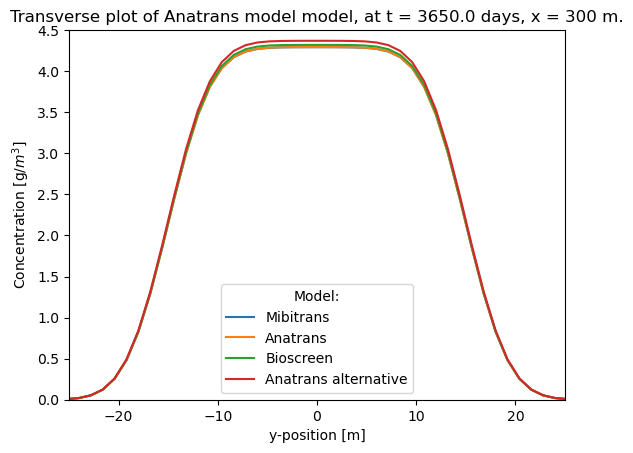

In [10]:
time = 365 * 10
mbt_results.transverse(time = time, x_position=300, color="C0", label="Mibitrans")
ana_results.transverse(time = time, x_position=300, color="C1", label="Anatrans")
bio_results.transverse(time = time, x_position=300, color="C2", label="Bioscreen")
alt_results.transverse(time = time, x_position=300, color="C3", label="Anatrans alternative")
plt.ylim([0,4.5])
plt.xlim([-25,25])
plt.legend(title="Model:")
plt.show()

For the concentration distribution perpendicular to the plume travel direction, we see that the same pattern: `Anatrans` and `Mibitrans` models deviate very little while `Bioscreen` and the `Alternative Anatrans` (both handling source depletion similarly) overestimate plume concentration.

## Analysis

Let's first define quantitative measures for the difference between the modelled plume concentrations. The reference here will always be the `Mibitrans` model implementation which provides the fully exact solution to the contaminant transport situation.

In [11]:
def absolute_error(a, b):
    """Calculate the absolute error."""
    return b - a
def relative_error(a, b):
    """Calculate the relative error."""
    return (b - a) / a

### Visualize relative error

Results shows that for `Anatrans`, the error with `Mibitrans` gradually changes of the plume length. However, for the alternative, there is peak in error at the advective front. In front and behind the advection, the alternative method resolves to the regular Anatrans results.

In [12]:
diff_ana = relative_error(mbt_results.cxyt[:,len(ana_results.y)//2,:],
                          ana_results.cxyt[:,len(ana_results.y)//2,:])
diff_bio = relative_error(mbt_results.cxyt[:,len(bio_results.y)//2,:],
                          bio_results.cxyt[:,len(bio_results.y)//2,:])
diff_alt = relative_error(mbt_results.cxyt[:,len(ana_results.y)//2,:],
                          alt_results.cxyt[:,len(ana_results.y)//2,:])

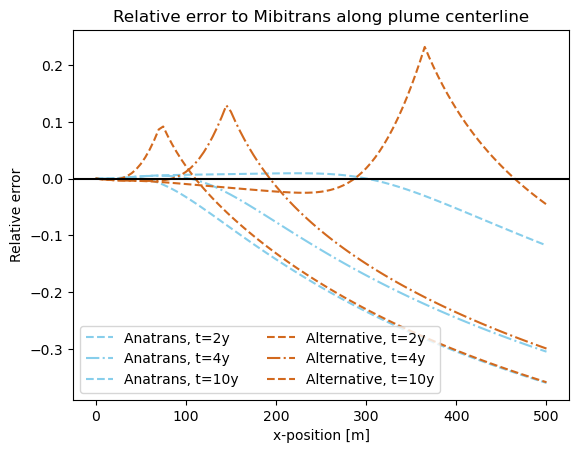

In [13]:
linestyle = ["--", "-.", "--"]
times = [1,3,9] #[9,29,49]

for i,t in enumerate(times):
    plt.plot(ana_results.x,
             diff_ana[t,:],
             color='skyblue',
             linestyle=linestyle[i],
             label="Anatrans, t={:.0f}y".format(mbt_object.t[t]/365)
             )

# for i,t in enumerate(times):
#     plt.plot(ana_results.x,
#              diff_bio[t,:],
#              color='C2',
#              linestyle=linestyle[i],
#              label="Alternative, t={}".format(t)
#              )

for i,t in enumerate(times):
    plt.plot(ana_results.x,
             diff_alt[t,:],
             color='chocolate',
             linestyle=linestyle[i],
             label="Alternative, t={:.0f}y".format(mbt_object.t[t]/365)
             )

plt.axhline(y=0, color='black')#, label="Mibitrans (ref)")

plt.legend(ncols = 2,loc='lower left')
plt.xlabel("x-position [m]")
plt.ylabel("Relative error")
plt.title("Relative error to Mibitrans along plume centerline")
plt.show()

### Impact of Decay

Let's study differences in the models regarding source depletion when there is also degredation (in the form of linear decay) during transport occurring. Why? The source depletion rate and the linear decay term are coupled. Both impact the reduction of contaminant source within the plume significantly. 

We thus redefine the attenuation parameters including a non-zero half-life time and rerun the models. 

We see that the plumes and differences between them show similar behavior.

In [14]:
lin_att = mbt.AttenuationParameters(
    bulk_density=1.7, #[g/m3]
    partition_coefficient=38, # [m^3/g]
    fraction_organic_carbon=5.7e-5, # [-]
    half_life=2 * 365 # [days]
)

In [15]:
ana_lin_object = mbt.Anatrans(hydro, lin_att, source, model)
ana_lin_results = ana_lin_object.run()

alt_lin_object = AnatransAlternativeSource(hydro, lin_att, source, model)
alt_lin_results = alt_lin_object.run()

mbt_lin_object = mbt.Mibitrans(hydro, lin_att, source, model)
mbt_lin_results = mbt_lin_object.run()

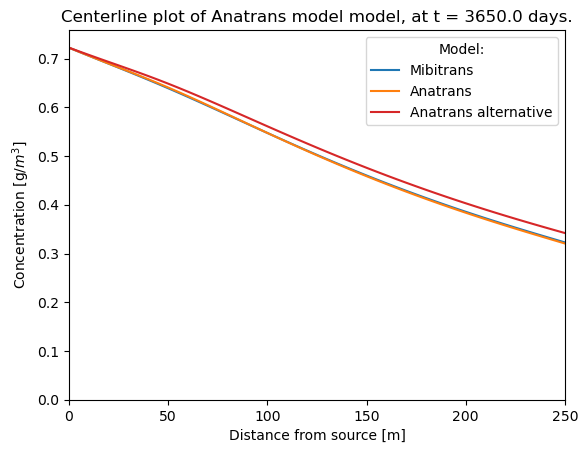

In [16]:
time = 365 * 10
mbt_lin_results.centerline(time = time, color="C0", label="Mibitrans")
ana_lin_results.centerline(time = time, color="C1", label="Anatrans")
alt_lin_results.centerline(time = time, color="C3", label="Anatrans alternative")
plt.xlim([0,250])
plt.legend(title="Model:")
plt.show()

In [17]:
diff_ana = relative_error(mbt_lin_results.cxyt[:,len(ana_results.y)//2,:],
                          ana_lin_results.cxyt[:,len(ana_results.y)//2,:])
diff_alt = relative_error(mbt_lin_results.cxyt[:,len(ana_results.y)//2,:],
                          alt_lin_results.cxyt[:,len(ana_results.y)//2,:])

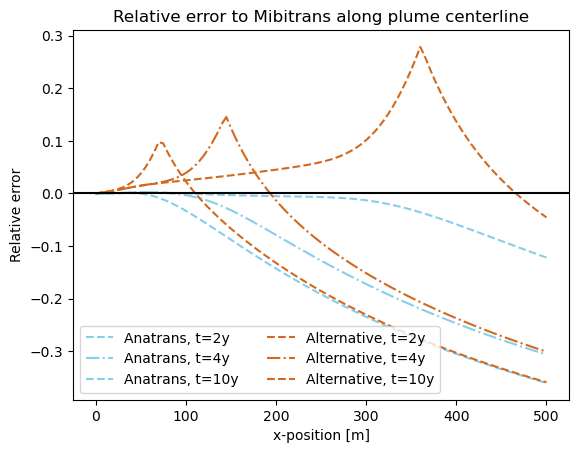

In [18]:
linestyle = ["--", "-.", "--"]
times = [1,3,9] #[9,29,49]

for i,t in enumerate(times):
    plt.plot(ana_results.x,
             diff_ana[t,:],
             color='skyblue',
             linestyle=linestyle[i],
             label="Anatrans, t={:.0f}y".format(mbt_object.t[t]/365)
             )
for i,t in enumerate(times):
    plt.plot(ana_results.x,
             diff_alt[t,:],
             color='chocolate',
             linestyle=linestyle[i],
             label="Alternative, t={:.0f}y".format(mbt_object.t[t]/365)
             )

plt.axhline(y=0, color='black')#, label="Mibitrans (ref)")

plt.legend(ncols = 2,loc='lower left')
plt.xlabel("x-position [m]")
plt.ylabel("Relative error")
plt.title("Relative error to Mibitrans along plume centerline")
plt.show()

### Impact of Source Size

Let's modify the settings to a much larger contaminant source and see the impact of different handling of source depletion for this case. Note that this examples now does not include linear decay. I.e. the only difference to the base case is the extended source mass.

In [19]:
large_source = mbt.SourceParameters(
    source_zone_boundary=np.array([15]), # [m]
    source_zone_concentration=np.array([10]), # [g/m3]
    depth=2, # [m]
    total_mass=500000 # [g]
)

In [20]:
mbt_large_object = mbt.Mibitrans(hydro, att, large_source, model)
mbt_large_results = mbt_large_object.run()

ana_large_object = mbt.Anatrans(hydro, att, large_source, model)
ana_large_results = ana_large_object.run()

alt_large_object = AnatransAlternativeSource(hydro, att, large_source, model)
alt_large_results = alt_large_object.run()


When increasing source mass, differences between two source depletion formulations become less apparent. Arguably, the alternative formulation comes closer to the exact Mibitrans solution than Anatrans does.

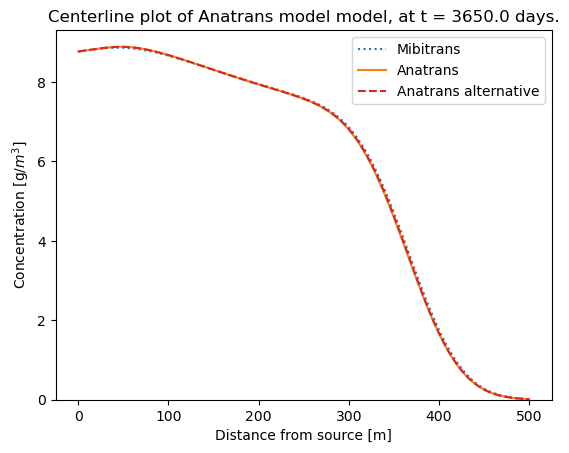

In [21]:
time = 365*10
mbt_large_results.centerline(time = time, color="C0", linestyle=":", label="Mibitrans")
ana_large_results.centerline(time = time, color="C1", label="Anatrans")
alt_large_results.centerline(time = time, color="C3", linestyle="--", label="Anatrans alternative")
plt.legend()
plt.show()

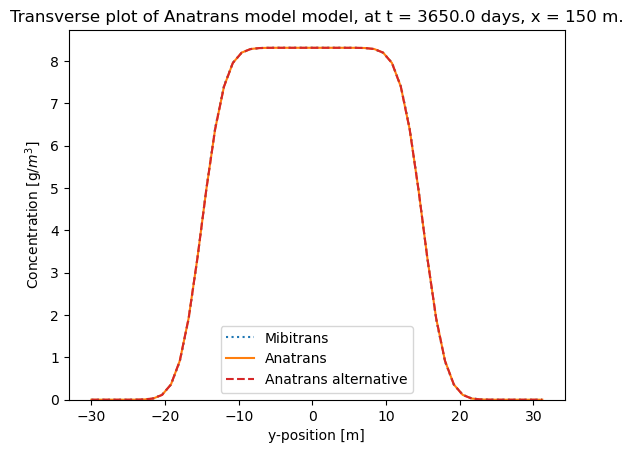

In [22]:
time = 365*10
mbt_large_results.transverse(time = time, x_position=150, color="C0", linestyle=":", label="Mibitrans")
ana_large_results.transverse(time = time, x_position=150, color="C1", label="Anatrans")
alt_large_results.transverse(time = time, x_position=150, color="C3", linestyle="--", label="Anatrans alternative")
plt.legend()
plt.show()

In [23]:
# The absolute error does a better job visualizing the differences here
diff_ana = absolute_error(mbt_large_results.cxyt[:,len(ana_results.y)//2,:],
                          ana_large_results.cxyt[:,len(ana_results.y)//2,:])
diff_alt = absolute_error(mbt_large_results.cxyt[:,len(ana_results.y)//2,:],
                          alt_large_results.cxyt[:,len(ana_results.y)//2,:])

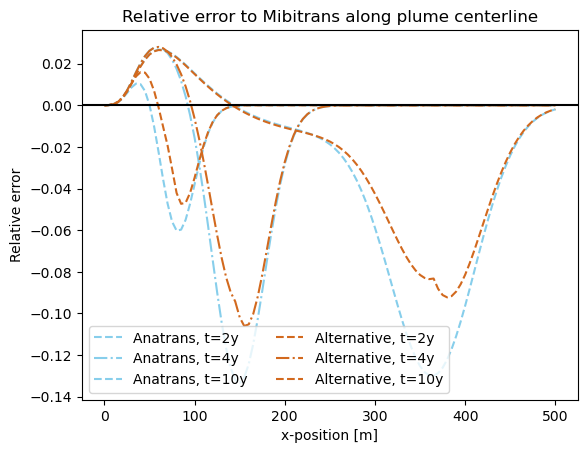

In [24]:
linestyle = ["--", "-.", "--"]

for i,t in enumerate(times):
    plt.plot(ana_results.x,
             diff_ana[t,:],
             color='skyblue',
             linestyle=linestyle[i],
             label="Anatrans, t={:.0f}y".format(mbt_object.t[t]/365)
             )
for i,t in enumerate(times):
    plt.plot(ana_results.x,
             diff_alt[t,:],
             color='chocolate',
             linestyle=linestyle[i],
             label="Alternative, t={:.0f}y".format(mbt_object.t[t]/365)
             )

plt.axhline(y=0, color='black')#, label="Mibitrans (ref)")

plt.legend(ncols = 2,loc='lower left')
plt.xlabel("x-position [m]")
plt.ylabel("Relative error")
plt.title("Relative error to Mibitrans along plume centerline")
plt.show()

**Interpretation**

As we see, models are close for large source mass, also supported by smaller absolute errors.
We thus conclude that the models show differences, but they only become relevant for high rates of source depletion.